In [ ]:
from collections import OrderedDict
import re
import os
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.notebook import tqdm

from google.colab import drive
drive.mount('/content/drive')
%cd 'drive/MyDrive/limits-of-icl/src'

!pip install wand munch

from eval import get_run_metrics, read_run_dir, get_model_from_run
from plot_utils import basic_plot, collect_results, relevant_model_names, plot_param_sweep, plot_experiment

%matplotlib inline
#%load_ext autoreload
#%autoreload 2

sns.set_theme('notebook', 'darkgrid')
palette = sns.color_palette('colorblind')

run_dir = "../models"

Mounted at /content/drive
/content/drive/MyDrive/limits-of-icl/src
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 4.0 MB/s eta 0:00:00


In [2]:
df = read_run_dir(run_dir)
df  # list all the runs in our run_dir

../models/linear_regression/nanogpt_local_100k_8/config.yaml
../models/linear_regression/nanogpt_local_100k_15/config.yaml
../models/linear_regression/nanogpt_mqa_100k/config.yaml
../models/linear_regression/nanogpt_rela_100k/config.yaml
../models/linear_regression/pretrained/config.yaml
../models/linear_regression/nanogpt_local_100k_5/config.yaml
../models/linear_regression/nanogpt_favor_100k/config.yaml
../models/linear_regression/nanogpt_softmax_100k/config.yaml
../models/linear_regression/dabb65f6-7e9b-4b32-b796-2a5af901efd2/config.yaml
../models/linear_regression/nanogpt_softmax_test/config.yaml
../models/linear_regression/nanogpt_rebased_100k/config.yaml


,run_id,task,model,kwargs,num_tasks,num_examples,n_dims,n_layer,n_head,run_name
4,pretrained,linear_regression,Transformer,,-1,-1,20,12,8,linear_regression_pretrained
8,dabb65f6-7e9b-4b32-b796-2a5af901efd2,linear_regression,Transformer,,-1,-1,5,12,8,linear_regression_toy
6,nanogpt_favor_100k,linear_regression,nanogpt_favor_100k,,-1,-1,20,12,8,nanogpt_favor_100k
1,nanogpt_local_100k_15,linear_regression,nanogpt_local_100k_15,,-1,-1,20,12,8,nanogpt_local_100k_15
5,nanogpt_local_100k_5,linear_regression,nanogpt_local_100k_5,,-1,-1,20,12,8,nanogpt_local_100k_5
0,nanogpt_local_100k_8,linear_regression,nanogpt_local_100k_8,,-1,-1,20,12,8,nanogpt_local_100k_8
2,nanogpt_mqa_100k,linear_regression,nanogpt_mqa_100k,,-1,-1,20,12,8,nanogpt_mqa_100k
10,nanogpt_rebased_100k,linear_regression,nanogpt_rebased_100k,,-1,-1,20,12,8,nanogpt_rebased_100k
3,nanogpt_rela_100k,linear_regression,nanogpt_rela_100k,,-1,-1,20,12,8,nanogpt_rela_100k
7,nanogpt_softmax_100k,linear_regression,nanogpt_softmax_100k,,-1,-1,20,12,8,nanogpt_softmax_100k


In [3]:
task = "linear_regression"
#task = "sparse_linear_regression"
#task = "decision_tree"
#task = "relu_2nn_regression"

# A list of models to compare - add more model run_ids here as needed
run_ids = ["nanogpt_local_100k_15", "nanogpt_local_100k_5", "nanogpt_mqa_100k", "nanogpt_softmax_100k", "nanogpt_rela_100k", "nanogpt_favor_100k", "nanogpt_rebased_100k"]
# run_ids = ["nanogpt_local_100k_5, nanogpt_local_100k_8, nanogpt_mqa_100k"]

recompute_metrics = True  # Set to True to force recomputation

# Load metrics from each model's metrics.json and combine them
results = {}
for run_id in run_ids:
    run_path = os.path.join(run_dir, task, run_id)
    metrics_path = os.path.join(run_path, "metrics.json")

    model_metrics = None

    # Try to load existing metrics.json if not forcing recompute
    if not recompute_metrics and os.path.exists(metrics_path):
        try:
            with open(metrics_path, "r") as f:
                model_metrics = json.load(f)
            print(f"Loaded cached metrics for {run_id}")
        except (json.JSONDecodeError, ValueError) as e:
            print(f"Warning: metrics.json for {run_id} is corrupted or empty. Recomputing...")
            model_metrics = None

    # If metrics don't exist, are corrupted, or recompute is forced, compute them
    if model_metrics is None:
        print(f"Computing metrics for {run_id}...")
        model_metrics = get_run_metrics(run_path, cache=not recompute_metrics)

    # Add this model's metrics to results, organizing by experiment type
    for experiment_name, model_results in model_metrics.items():
        if experiment_name not in results:
            results[experiment_name] = {}
        # Add this model's results under the run_id as the model name
        for model_name, metrics in model_results.items():
            # Use run_id as the model identifier to distinguish different models
            combined_name = f"{run_id}" if ("nanogpt" in model_name or "gpt2" in model_name) else model_name
            results[experiment_name][combined_name] = metrics

# Optionally save combined results for reference
with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

print(f"\nLoaded metrics from {len(run_ids)} models")
print(f"Experiment types: {list(results.keys())}")

Computing metrics for nanogpt_local_100k_15...
../models/linear_regression/nanogpt_local_100k_15/config.yaml
number of parameters: 9.48M
odict_keys(['_read_in.weight', '_read_in.bias', '_backbone.transformer.wpe.weight', '_backbone.transformer.h.0.ln_1.weight', '_backbone.transformer.h.0.ln_1.bias', '_backbone.transformer.h.0.attn.c_attn.weight', '_backbone.transformer.h.0.attn.c_attn.bias', '_backbone.transformer.h.0.attn.c_proj.weight', '_backbone.transformer.h.0.attn.c_proj.bias', '_backbone.transformer.h.0.ln_2.weight', '_backbone.transformer.h.0.ln_2.bias', '_backbone.transformer.h.0.mlp.c_fc.weight', '_backbone.transformer.h.0.mlp.c_fc.bias', '_backbone.transformer.h.0.mlp.c_proj.weight', '_backbone.transformer.h.0.mlp.c_proj.bias', '_backbone.transformer.h.1.ln_1.weight', '_backbone.transformer.h.1.ln_1.bias', '_backbone.transformer.h.1.attn.c_attn.weight', '_backbone.transformer.h.1.attn.c_attn.bias', '_backbone.transformer.h.1.attn.c_proj.weight', '_backbone.transformer.h.1.at

100%|██████████| 180/180 [01:06<00:00,  2.71it/s]


{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [5.261407375335693], 'std': [11.141200065612793], 'bootstrap_low': [4.781447410583496], 'bootstrap_high': [5.771700382232666]}}, 'scaled_query_scale=0.1': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [0.3474103808403015], 'std': [0.944072961807251], 'bootstrap_low': [0.3069075644016266], 'bootstrap_high': [0.3934921622276306]}}, 'scaled_query_scale=0.30000000000000004': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [0.8438466787338257], 'std': [2.4933159351348877], 'bootstrap_low': [0.7344948649406433], 'bootstrap_high': [0.9611912965774536]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [1.4859976768493652], 'std': [3.2704060077667236], 'bootstrap_low': [1.3495837450027466], 'bootstrap_high': [1.6497316360473633]}}, 'scaled_query_scale=0.7000000000000001': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [2.70519

100%|██████████| 180/180 [01:05<00:00,  2.74it/s]


{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [17.85605239868164], 'std': [28.36227798461914], 'bootstrap_low': [16.622577667236328], 'bootstrap_high': [19.25494384765625]}}, 'scaled_query_scale=0.1': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [0.7186012268066406], 'std': [1.2333574295043945], 'bootstrap_low': [0.6657754778862], 'bootstrap_high': [0.7766638994216919]}}, 'scaled_query_scale=0.30000000000000004': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [2.1365597248077393], 'std': [3.81516170501709], 'bootstrap_low': [1.9714486598968506], 'bootstrap_high': [2.3127987384796143]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [5.664724349975586], 'std': [8.969475746154785], 'bootstrap_low': [5.244305610656738], 'bootstrap_high': [6.0778489112854]}}, 'scaled_query_scale=0.7000000000000001': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [9.711723327636719

...

{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=rela': {'mean': [0.14389701187610626], 'std': [0.2906119227409363], 'bootstrap_low': [0.13049188256263733], 'bootstrap_high': [0.15773174166679382]}}, 'scaled_query_scale=0.1': {'nanogpt_embd=256_layer=12_head=8_attn=rela': {'mean': [0.014328124932944775], 'std': [0.021220868453383446], 'bootstrap_low': [0.013318243436515331], 'bootstrap_high': [0.015340052545070648]}}, 'scaled_query_scale=0.30000000000000004': {'nanogpt_embd=256_layer=12_head=8_attn=rela': {'mean': [0.025291308760643005], 'std': [0.04699590802192688], 'bootstrap_low': [0.023148560896515846], 'bootstrap_high': [0.02764715813100338]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=rela': {'mean': [0.0447763092815876], 'std': [0.08725182712078094], 'bootstrap_low': [0.04105353355407715], 'bootstrap_high': [0.04892266169190407]}}, 'scaled_query_scale=0.7000000000000001': {'nanogpt_embd=256_layer=12_head=8_attn=rela': {'mean': [0.07069842517375946], '

100%|██████████| 180/180 [02:10<00:00,  1.38it/s]


{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=favor': {'mean': [0.09132476150989532], 'std': [0.18154561519622803], 'bootstrap_low': [0.082981638610363], 'bootstrap_high': [0.10012020170688629]}}, 'scaled_query_scale=0.1': {'nanogpt_embd=256_layer=12_head=8_attn=favor': {'mean': [0.011195313185453415], 'std': [0.017143642529845238], 'bootstrap_low': [0.010464346036314964], 'bootstrap_high': [0.011999504640698433]}}, 'scaled_query_scale=0.30000000000000004': {'nanogpt_embd=256_layer=12_head=8_attn=favor': {'mean': [0.016590464860200882], 'std': [0.02573317103087902], 'bootstrap_low': [0.015446278266608715], 'bootstrap_high': [0.017758606001734734]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=favor': {'mean': [0.028796564787626266], 'std': [0.049551431089639664], 'bootstrap_low': [0.02653064765036106], 'bootstrap_high': [0.031183069571852684]}}, 'scaled_query_scale=0.7000000000000001': {'nanogpt_embd=256_layer=12_head=8_attn=favor': {'mean': [0.044020235538

100%|██████████| 180/180 [01:58<00:00,  1.52it/s]


{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=rebased': {'mean': [0.0978986918926239], 'std': [0.19079919159412384], 'bootstrap_low': [0.08918420970439911], 'bootstrap_high': [0.10690043866634369]}}, 'scaled_query_scale=0.1': {'nanogpt_embd=256_layer=12_head=8_attn=rebased': {'mean': [0.017446845769882202], 'std': [0.0483771376311779], 'bootstrap_low': [0.01549050398170948], 'bootstrap_high': [0.019846756011247635]}}, 'scaled_query_scale=0.30000000000000004': {'nanogpt_embd=256_layer=12_head=8_attn=rebased': {'mean': [0.017123589292168617], 'std': [0.025244763121008873], 'bootstrap_low': [0.01592608354985714], 'bootstrap_high': [0.018230250105261803]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=rebased': {'mean': [0.02812071144580841], 'std': [0.05079363286495209], 'bootstrap_low': [0.02586623653769493], 'bootstrap_high': [0.030607333406805992]}}, 'scaled_query_scale=0.7000000000000001': {'nanogpt_embd=256_layer=12_head=8_attn=rebased': {'mean': [0.046426

In [ ]:
state = torch.load("../models/linear_regression/nanogpt_softmax_test/state.pt", map_location=torch.device('cpu'))

In [ ]:
state['model_state_dict'].keys()

odict_keys(['_read_in.weight', '_read_in.bias', '_backbone.transformer.wpe.weight', '_backbone.transformer.h.0.ln_1.weight', '_backbone.transformer.h.0.ln_1.bias', '_backbone.transformer.h.0.attn.c_attn.weight', '_backbone.transformer.h.0.attn.c_attn.bias', '_backbone.transformer.h.0.attn.c_proj.weight', '_backbone.transformer.h.0.attn.c_proj.bias', '_backbone.transformer.h.0.ln_2.weight', '_backbone.transformer.h.0.ln_2.bias', '_backbone.transformer.h.0.mlp.c_fc.weight', '_backbone.transformer.h.0.mlp.c_fc.bias', '_backbone.transformer.h.0.mlp.c_proj.weight', '_backbone.transformer.h.0.mlp.c_proj.bias', '_backbone.transformer.h.1.ln_1.weight', '_backbone.transformer.h.1.ln_1.bias', '_backbone.transformer.h.1.attn.c_attn.weight', '_backbone.transformer.h.1.attn.c_attn.bias', '_backbone.transformer.h.1.attn.c_proj.weight', '_backbone.transformer.h.1.attn.c_proj.bias', '_backbone.transformer.h.1.ln_2.weight', '_backbone.transformer.h.1.ln_2.bias', '_backbone.transformer.h.1.mlp.c_fc.weig

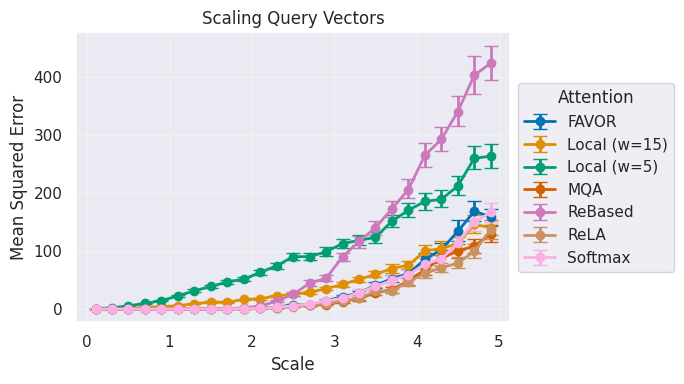

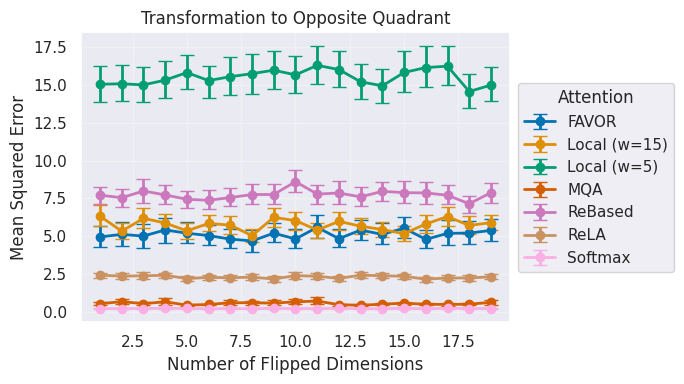

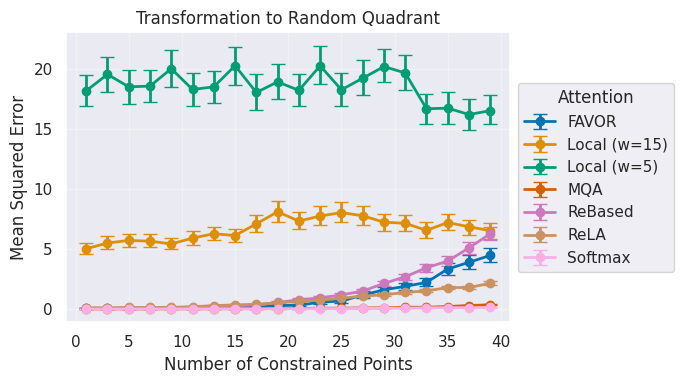

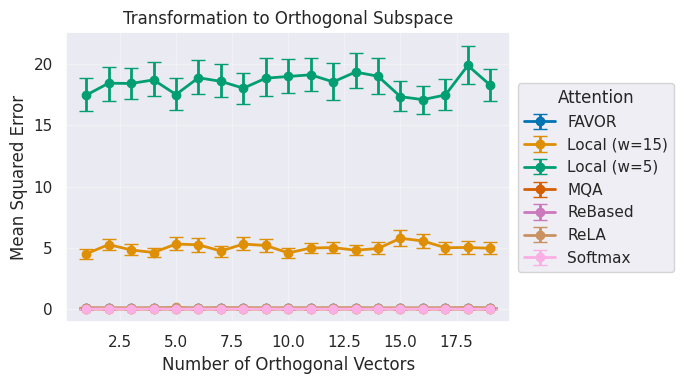

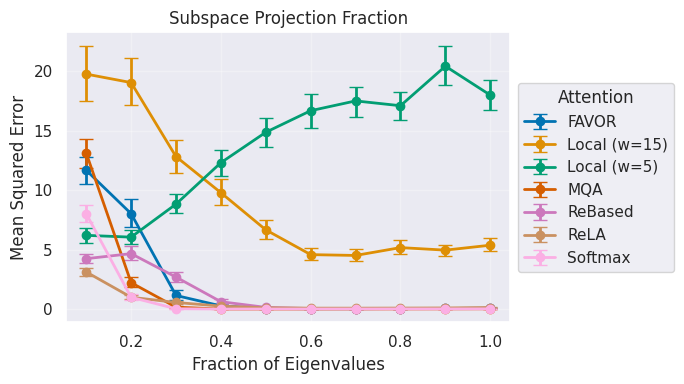

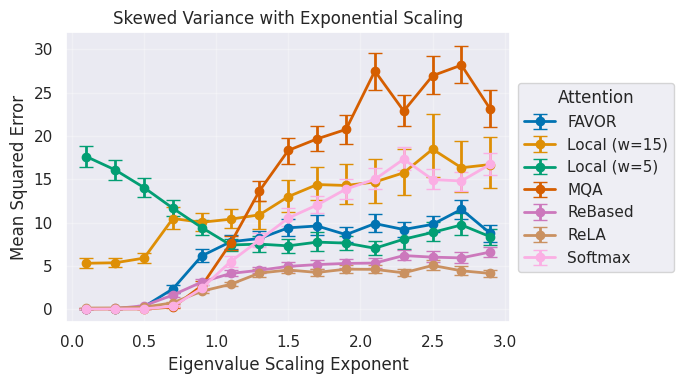

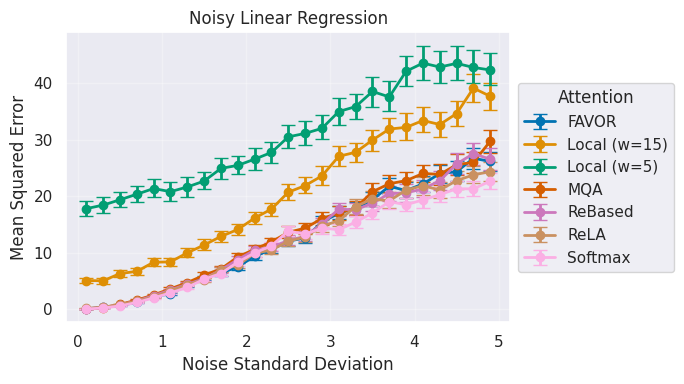

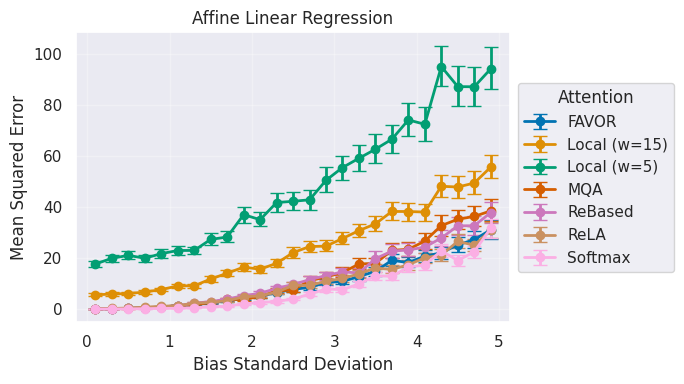

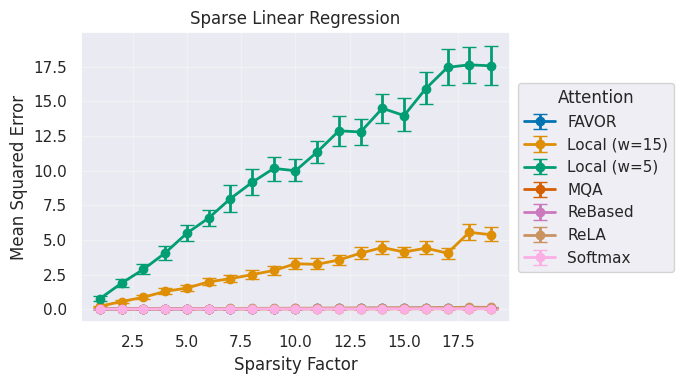

In [4]:
# Plot all parameter sweep experiments (comparing all models)
figs = plot_param_sweep(results)

for fig in figs:
    plt.show()

### Parameter Sweep Plots in a 3x3 Grid

To display all parameter sweep plots in a single 3x3 grid, I will re-process the `results` dictionary to identify different parameter sweeps and plot each one as a subplot in a new, combined figure.

ValueError: 'x' and 'y' must have the same size

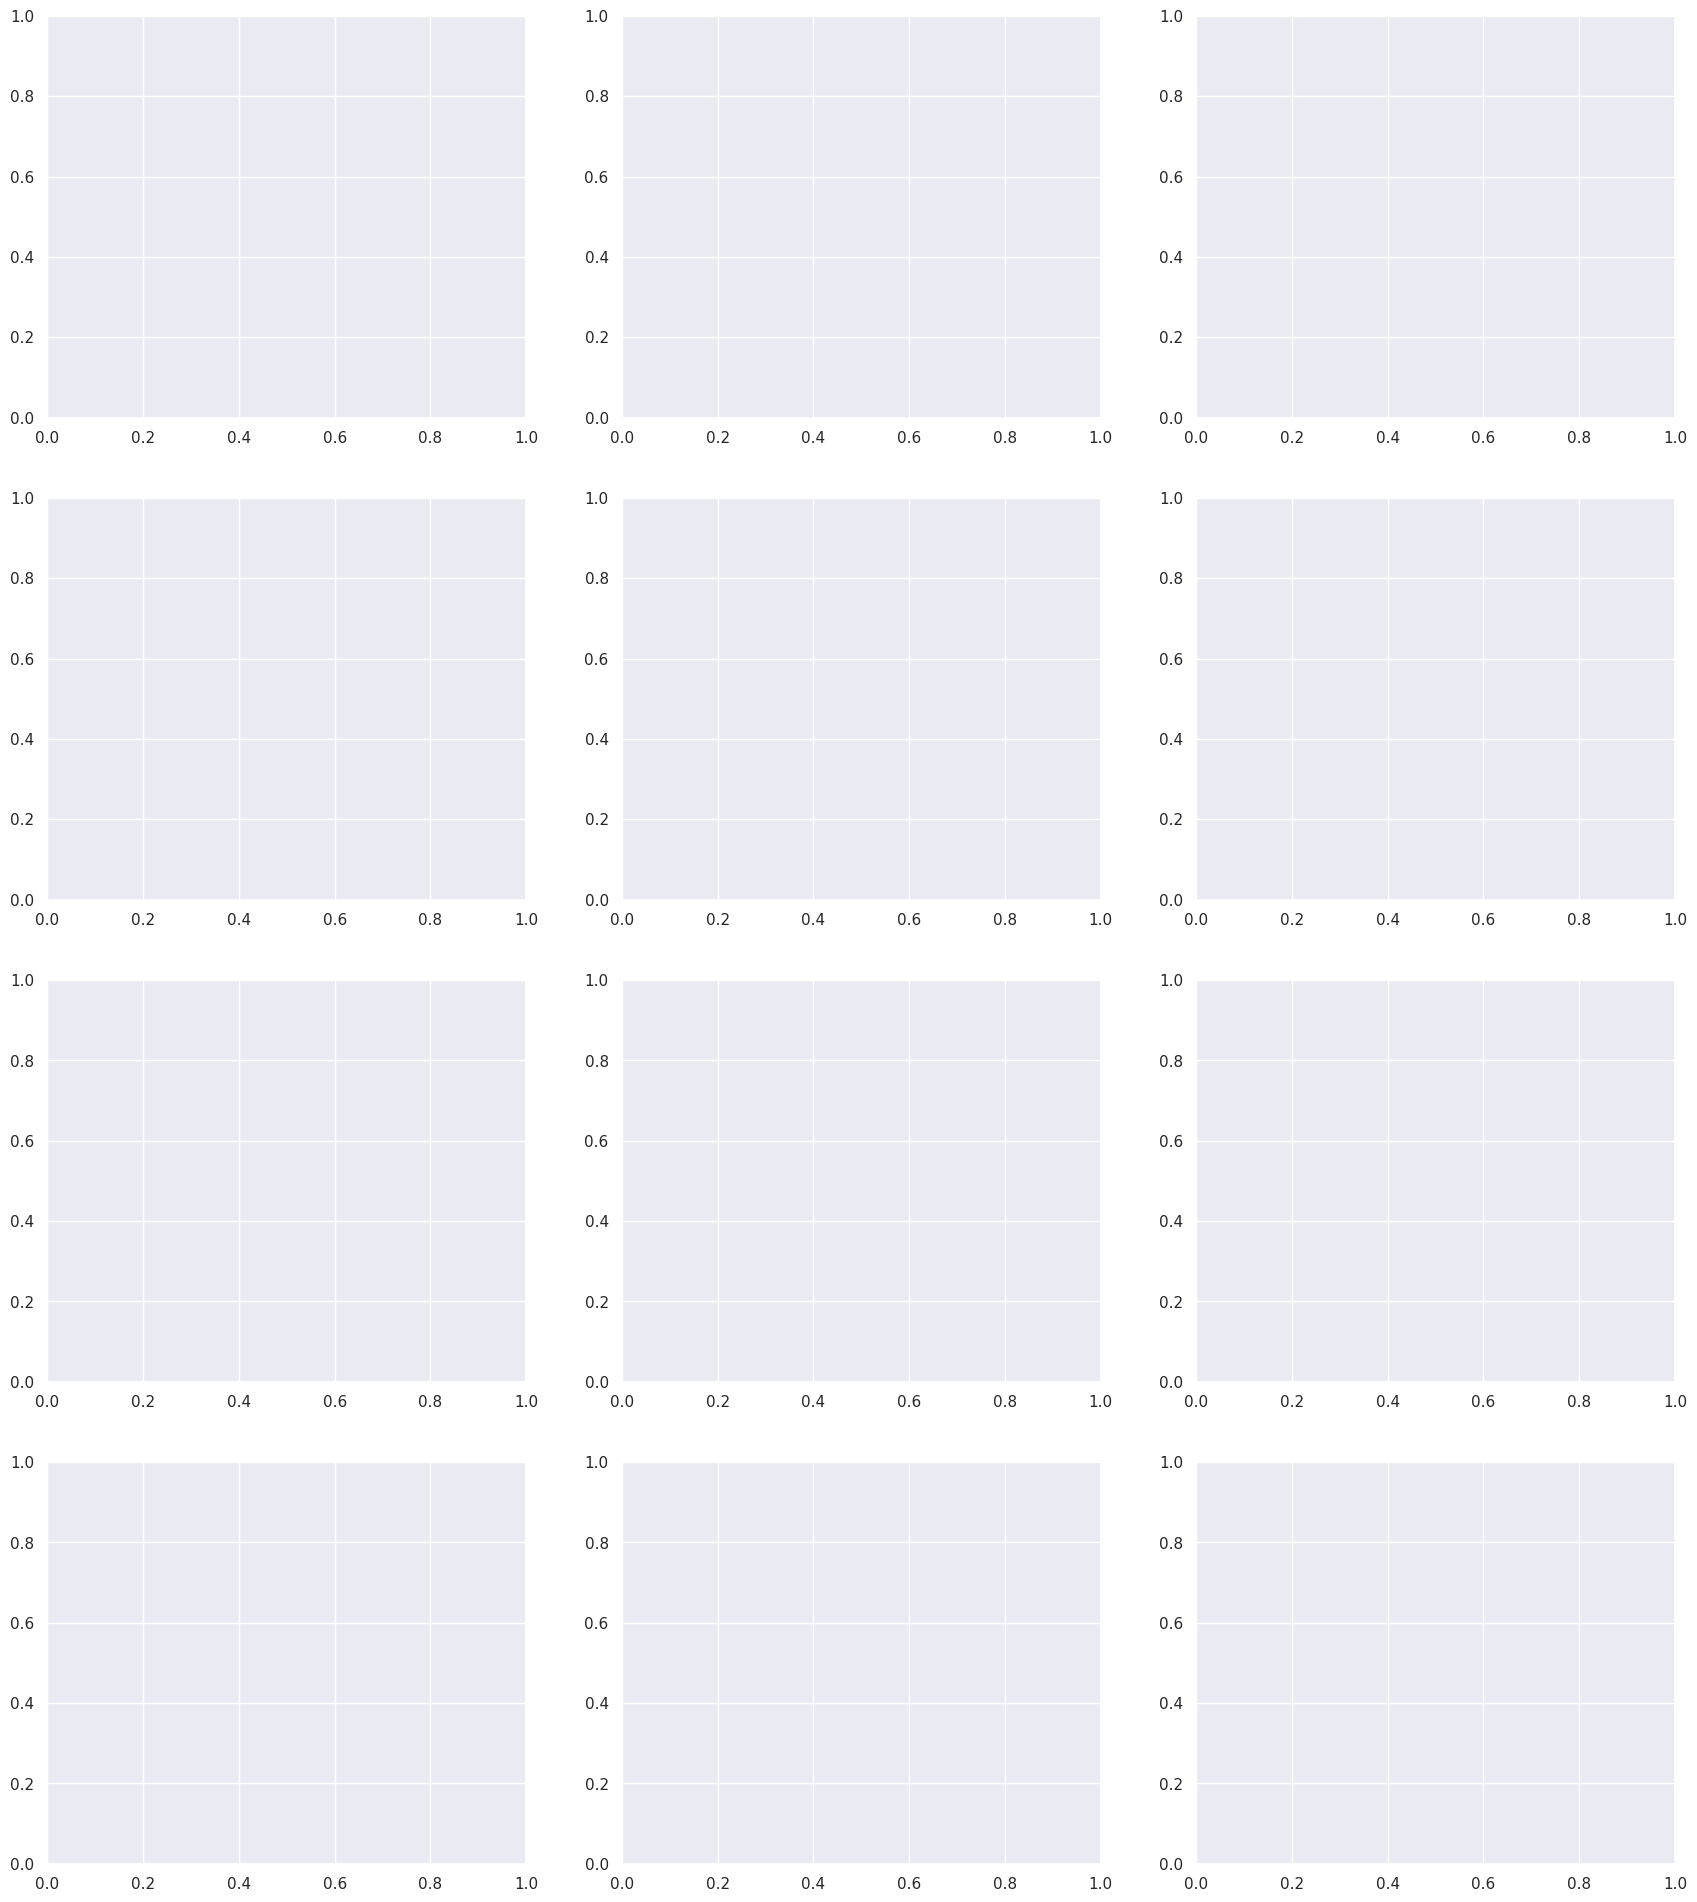

In [5]:
import math
import re

def group_sweeps_and_extract_params(results_dict):
    grouped = {}
    for exp_name, exp_data in results_dict.items():
        # Use regex to find patterns like 'param_name=value'
        match = re.match(r'([a-zA-Z0-9_]+)=([\d.]+)', exp_name)

        if match:
            param_group_key = match.group(1) # e.g., 'scaled_query_scale'
            param_value = float(match.group(2))

            if param_group_key not in grouped:
                grouped[param_group_key] = []

            grouped[param_group_key].append({'exp_name': exp_name, 'param_value': param_value, 'data': exp_data})

    # Sort each group by param_value
    for key in grouped:
        grouped[key] = sorted(grouped[key], key=lambda x: x['param_value'])

    return grouped

# Group the results by the parameter being swept
grouped_sweep_results = group_sweeps_and_extract_params(results)
sweep_keys = list(grouped_sweep_results.keys())

# Determine grid dimensions
num_sweeps = len(sweep_keys)
num_cols = 3 # Desired number of columns
num_rows = math.ceil(num_sweeps / num_cols)

# Create a new figure and a grid of subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 7, num_rows * 6), squeeze=False)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, sweep_key in enumerate(sweep_keys):
    ax = axes[i]
    current_sweep_data = grouped_sweep_results[sweep_key]

    # Prepare data for plotting this specific sweep
    x_values = [item['param_value'] for item in current_sweep_data]

    # Collect y_values, bootstrap_low, and bootstrap_high for each model across this sweep
    model_plot_data = {}
    for item in current_sweep_data:
        for model_name, metrics in item['data'].items():
            if model_name not in model_plot_data:
                model_plot_data[model_name] = {'mean': [], 'low': [], 'high': []}

            if metrics and 'mean' in metrics and len(metrics['mean']) > 0:
                model_plot_data[model_name]['mean'].append(metrics['mean'][0])
                model_plot_data[model_name]['low'].append(metrics['bootstrap_low'][0])
                model_plot_data[model_name]['high'].append(metrics['bootstrap_high'][0])
            else:
                model_plot_data[model_name]['mean'].append(float('nan')) # Handle missing data
                model_plot_data[model_name]['low'].append(float('nan'))
                model_plot_data[model_name]['high'].append(float('nan'))

    # Plot each model's results for this sweep on the current subplot with error bars
    for model_name, data in model_plot_data.items():
        yerr_lower = [data['mean'][j] - data['low'][j] for j in range(len(data['mean']))]
        yerr_upper = [data['high'][j] - data['mean'][j] for j in range(len(data['mean']))]
        yerr = [yerr_lower, yerr_upper]
        ax.errorbar(x_values, data['mean'], yerr=yerr, label=model_name, marker='o', markersize=4, linestyle='-', capsize=3)

    # Set title and labels for the subplot
    title_name = sweep_key.replace('_', ' ').title()
    x_label_name = sweep_key.split('_')[-1].title() # e.g., 'Scale' or 'Num_Flipped'

    ax.set_title(title_name, fontsize=12)
    ax.set_xlabel(x_label_name, fontsize=10)
    ax.set_ylabel('Mean Loss', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize='x-small', loc='best')

# Hide any unused subplots if num_sweeps is not a perfect square of num_cols*num_rows
for j in range(num_sweeps, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Parameter Sweep Experiments', fontsize=16, y=1.02) # Add an overall title
plt.show()